In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
print("="*70)
print("TRANSFER LEARNING: EfficientNetB0")
print("="*70)

# Enable mixed precision for faster training
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)
print('✓ Mixed precision enabled: Compute=float16, Variables=float32')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPU detected: {gpus[0].name}")
else:
    print("⚠ No GPU detected - training will be slow!")

TRANSFER LEARNING: EfficientNetB0
✓ Mixed precision enabled: Compute=float16, Variables=float32
✓ GPU detected: /physical_device:GPU:0


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import zipfile

zip_path = '/content/drive/MyDrive/archive (2).zip'  # change this to your actual path
extract_path = '/content/ham10000'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [8]:
DATA_PATH = '/content/'

df = pd.read_csv('/content/ham10000/HAM10000_metadata.csv')
print(f"\n✓ Total images: {len(df)}")

img_dir_1 = '/content/ham10000/HAM10000_images_part_1'
img_dir_2 = '/content/ham10000/HAM10000_images_part_2'

df['path'] = df['image_id'].apply(
    lambda x: os.path.join(img_dir_1, x + '.jpg')
    if os.path.exists(os.path.join(img_dir_1, x + '.jpg'))
    else os.path.join(img_dir_2, x + '.jpg')
)

df['label'] = pd.Categorical(df['dx']).codes
class_names = sorted(df['dx'].unique())


✓ Total images: 10015


In [39]:
df.head(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/ham10000/HAM10000_images_part_1/ISIC_...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/ham10000/HAM10000_images_part_1/ISIC_...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/ham10000/HAM10000_images_part_1/ISIC_...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/ham10000/HAM10000_images_part_1/ISIC_...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/ham10000/HAM10000_images_part_2/ISIC_...,2


In [9]:
print("\nBalancing dataset (800 samples per class)...")
balanced_dfs = []
for lesion_type in df['dx'].unique():
    class_df = df[df['dx'] == lesion_type]
    # Reduced from 1000 to 800 to save memory
    sampled = class_df.sample(n=800, replace=True, random_state=42)
    balanced_dfs.append(sampled)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✓ Total samples: {len(df_balanced)}")


Balancing dataset (800 samples per class)...
✓ Total samples: 5600


In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df_balanced['path'].values,
    df_balanced['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label'].values
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"✓ Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

✓ Train: 4480 | Val: 560 | Test: 560


In [11]:
print("\nLoading images (224x224 for EfficientNet)...")
IMG_SIZE = 224  # EfficientNet optimal size

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype('float32')  # Don't normalize yet - EfficientNet does it

X_train_imgs = np.array([load_image(p) for p in tqdm(X_train, desc="Train")])
X_val_imgs = np.array([load_image(p) for p in tqdm(X_val, desc="Val  ")])
X_test_imgs = np.array([load_image(p) for p in tqdm(X_test, desc="Test ")])

print(f"✓ Data shape: {X_train_imgs.shape}")

y_train_cat = keras.utils.to_categorical(y_train, 7)
y_val_cat = keras.utils.to_categorical(y_val, 7)
y_test_cat = keras.utils.to_categorical(y_test, 7)


Loading images (224x224 for EfficientNet)...


Test : 100%|██████████| 560/560 [00:03<00:00, 165.06it/s]


✓ Data shape: (4480, 224, 224, 3)


In [12]:
print("\n" + "="*70)
print("DATA AUGMENTATION")
print("="*70)

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

# Validation uses only preprocessing (no augmentation)
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

print("✓ Training: rotation, flips, zoom, brightness")
print("✓ Preprocessing: EfficientNet normalization")


DATA AUGMENTATION
✓ Training: rotation, flips, zoom, brightness
✓ Preprocessing: EfficientNet normalization


In [13]:
print("\n" + "="*70)
print("BUILDING EfficientNetB0 MODEL")
print("="*70)

def build_efficientnet_model(trainable_base=False):
    """
    EfficientNetB0 Transfer Learning Model

    Strategy:
    1. Load pre-trained weights (ImageNet)
    2. Freeze base initially
    3. Train only top layers
    4. Later: unfreeze and fine-tune
    """

    # Load pre-trained EfficientNetB0
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg'  # Global average pooling
    )

    base_model.trainable = trainable_base

    # Build classifier on top
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)

    # Custom classifier head
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    # Output layer (float32 for numerical stability)
    outputs = layers.Dense(7, activation='softmax', dtype='float32')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model, base_model

model, base_model = build_efficientnet_model(trainable_base=False)

print(f"✓ EfficientNetB0 loaded with ImageNet weights")
print(f"✓ Base model frozen: {not base_model.trainable}")
print(f"✓ Trainable params: {model.count_params():,}")
print(f"✓ Total params: {np.sum([keras.backend.count_params(w) for w in model.weights]):,}")


BUILDING EfficientNetB0 MODEL
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✓ EfficientNetB0 loaded with ImageNet weights
✓ Base model frozen: True
✓ Trainable params: 4,417,450
✓ Total params: 4,417,450.0


In [14]:
print("\n" + "="*70)
print("PHASE 1: TRAINING CLASSIFIER HEAD (Base Frozen)")
print("="*70)

# Calculate class weights (light)
class_weights_raw = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: min(w, 1.5) for i, w in enumerate(class_weights_raw)}
print(f"✓ Class weights: {class_weights_dict}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)


PHASE 1: TRAINING CLASSIFIER HEAD (Base Frozen)
✓ Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}


In [15]:
callbacks_phase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'efficientnet_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\n🚀 Training Phase 1...")
BATCH_SIZE = 16  # Reduced for free Colab


🚀 Training Phase 1...


In [16]:
history_phase1 = model.fit(
    datagen.flow(X_train_imgs, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(X_val_imgs, y_val_cat, batch_size=BATCH_SIZE, shuffle=False),
    epochs=25,
    callbacks=callbacks_phase1,
    class_weight=class_weights_dict,
    verbose=2
)

Epoch 1/25

Epoch 1: val_accuracy improved from -inf to 0.57500, saving model to efficientnet_phase1.keras
280/280 - 142s - 506ms/step - accuracy: 0.3848 - auc: 0.7633 - loss: 1.7391 - val_accuracy: 0.5750 - val_auc: 0.8796 - val_loss: 1.2138 - learning_rate: 1.0000e-03
Epoch 2/25

Epoch 2: val_accuracy did not improve from 0.57500
280/280 - 58s - 207ms/step - accuracy: 0.4917 - auc: 0.8485 - loss: 1.3603 - val_accuracy: 0.5714 - val_auc: 0.9041 - val_loss: 1.0778 - learning_rate: 1.0000e-03
Epoch 3/25

Epoch 3: val_accuracy improved from 0.57500 to 0.60536, saving model to efficientnet_phase1.keras
280/280 - 60s - 214ms/step - accuracy: 0.5225 - auc: 0.8669 - loss: 1.2646 - val_accuracy: 0.6054 - val_auc: 0.9176 - val_loss: 0.9947 - learning_rate: 1.0000e-03
Epoch 4/25

Epoch 4: val_accuracy did not improve from 0.60536
280/280 - 59s - 211ms/step - accuracy: 0.5513 - auc: 0.8793 - loss: 1.2023 - val_accuracy: 0.6018 - val_auc: 0.9159 - val_loss: 1.0015 - learning_rate: 1.0000e-03
Epoc

In [17]:
print("\n" + "="*70)
print("PHASE 2: FINE-TUNING (Unfreezing Base)")
print("="*70)

# Load best model from phase 1
model = keras.models.load_model('efficientnet_phase1.keras')

# Unfreeze base model for fine-tuning
base_model.trainable = True

# Freeze first 100 layers (keep early features stable)
for layer in base_model.layers[:100]:
    layer.trainable = False

print(f"✓ Base model unfrozen")
print(f"✓ First 100 layers frozen (feature extraction)")
print(f"✓ Fine-tuning remaining {len([l for l in base_model.layers if l.trainable])} layers")


PHASE 2: FINE-TUNING (Unfreezing Base)
✓ Base model unfrozen
✓ First 100 layers frozen (feature extraction)
✓ Fine-tuning remaining 139 layers


In [18]:
# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # 10x lower
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'efficientnet_final.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\n🚀 Training Phase 2 (Fine-tuning)...")


🚀 Training Phase 2 (Fine-tuning)...


In [19]:
history_phase2 = model.fit(
    datagen.flow(X_train_imgs, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(X_val_imgs, y_val_cat, batch_size=BATCH_SIZE, shuffle=False),
    epochs=30,
    callbacks=callbacks_phase2,
    class_weight=class_weights_dict,
    verbose=2
)


Epoch 1/30

Epoch 1: val_accuracy improved from -inf to 0.73571, saving model to efficientnet_final.keras
280/280 - 117s - 417ms/step - accuracy: 0.6812 - auc: 0.9403 - loss: 0.8434 - val_accuracy: 0.7357 - val_auc: 0.9551 - val_loss: 0.7302 - learning_rate: 1.0000e-04
Epoch 2/30

Epoch 2: val_accuracy improved from 0.73571 to 0.74286, saving model to efficientnet_final.keras
280/280 - 59s - 210ms/step - accuracy: 0.6732 - auc: 0.9390 - loss: 0.8505 - val_accuracy: 0.7429 - val_auc: 0.9571 - val_loss: 0.7176 - learning_rate: 1.0000e-04
Epoch 3/30

Epoch 3: val_accuracy did not improve from 0.74286
280/280 - 58s - 205ms/step - accuracy: 0.6971 - auc: 0.9421 - loss: 0.8303 - val_accuracy: 0.7429 - val_auc: 0.9564 - val_loss: 0.7225 - learning_rate: 1.0000e-04
Epoch 4/30

Epoch 4: val_accuracy improved from 0.74286 to 0.74464, saving model to efficientnet_final.keras
280/280 - 59s - 212ms/step - accuracy: 0.6900 - auc: 0.9430 - loss: 0.8254 - val_accuracy: 0.7446 - val_auc: 0.9575 - val_l

In [29]:


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00005),  # ← Changed from 0.0001
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,  # ← Changed from 12
        restore_best_weights=True,
        verbose=1
    ),
    # ... rest same
]

history_phase2 = model.fit(
    datagen.flow(X_train_imgs, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=val_datagen.flow(X_val_imgs, y_val_cat, batch_size=BATCH_SIZE, shuffle=False),
    epochs=50,  # ← Changed from 30
    callbacks=callbacks_phase2,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 119s 285ms/step - accuracy: 0.7003 - auc: 0.9501 - loss: 0.7702 - val_accuracy: 0.7500 - val_auc: 0.9600 - val_loss: 0.6920
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 59s 209ms/step - accuracy: 0.6991 - auc: 0.9445 - loss: 0.8120 - val_accuracy: 0.7375 - val_auc: 0.9601 - val_loss: 0.6916
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 59s 211ms/step - accuracy: 0.6998 - auc: 0.9460 - loss: 0.8011 - val_accuracy: 0.7429 - val_auc: 0.9603 - val_loss: 0.6892
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 59s 209ms/step - accuracy: 0.7119 - auc: 0.9492 - loss: 0.7751 - val_accuracy: 0.7554 - val_auc: 0.9603 - val_loss: 0.6894
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 59s 211ms/step - accuracy: 0.7103 - auc: 0.9466 - loss: 0.7937 - val_accuracy: 0.7446 - val_auc: 0.9601 - val_loss: 0.6905
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 60s 213ms/step - accuracy: 0.6882 - auc: 0.9420 - loss: 0.8283 - val_accuracy: 0.7500 - val_auc: 0.9605 - val_loss: 0.6876
Epoch 7/50
280/280 ━━

In [20]:
print("\n" + "="*70)
print("FINAL EVALUATION")
print("="*70)

model = keras.models.load_model('efficientnet_final.keras')

# Preprocess test images
X_test_preprocessed = tf.keras.applications.efficientnet.preprocess_input(
    X_test_imgs.copy()
)

y_pred_proba = model.predict(X_test_preprocessed, verbose=0, batch_size=BATCH_SIZE)
y_pred = np.argmax(y_pred_proba, axis=1)

test_loss, test_acc, test_auc = model.evaluate(
    X_test_preprocessed, y_test_cat, verbose=0, batch_size=BATCH_SIZE
)

print(f"TRANSFER LEARNING:        {test_acc*100:.2f}%")
print(f"{'='*70}")
print(f"\nTest AUC:  {test_auc:.4f}")
print(f"Test Loss: {test_loss:.4f}\n")

if test_acc >= 0.80:
    print("🎉 SUCCESS! Target >80% achieved!")
elif test_acc >= 0.78:
    print("✓ Very close! Consider training a bit longer")
else:
    print("⚠ Below target - may need more fine-tuning")

# Detailed report
print("\n" + "="*70)
print("PER-CLASS PERFORMANCE")
print("="*70)
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))


FINAL EVALUATION

BASELINE (Custom CNN):    65.43%
IMPROVED (Deeper CNN):    ~75-78%
TRANSFER LEARNING:        77.32%

Test AUC:  0.9647
Test Loss: 0.6589

⚠ Below target - may need more fine-tuning

PER-CLASS PERFORMANCE
              precision    recall  f1-score   support

       akiec      0.843     0.738     0.787        80
         bcc      0.737     0.700     0.718        80
         bkl      0.663     0.688     0.675        80
          df      0.806     0.938     0.867        80
         mel      0.598     0.650     0.623        80
          nv      0.875     0.700     0.778        80
        vasc      0.920     1.000     0.958        80

    accuracy                          0.773       560
   macro avg      0.777     0.773     0.772       560
weighted avg      0.777     0.773     0.772       560



In [22]:
# Accuracy plot
axes[0].plot(all_acc, label='Train', linewidth=2, color='blue')
axes[0].plot(all_val_acc, label='Validation', linewidth=2, color='orange')
axes[0].axhline(y=0.6543, color='red', linestyle='--', label='Baseline (65%)', linewidth=2)
axes[0].axhline(y=0.80, color='green', linestyle='--', label='Target (80%)', linewidth=2)
axes[0].axvline(x=len(history_phase1.history['accuracy']), color='gray',
                linestyle=':', label='Phase 1→2', linewidth=2)
axes[0].set_title('Model Accuracy (2-Phase Training)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

In [25]:
# Loss plot
axes[1].plot(all_loss, label='Train', linewidth=2, color='blue')
axes[1].plot(all_val_loss, label='Validation', linewidth=2, color='orange')
axes[1].axvline(x=len(history_phase1.history['loss']), color='gray',
                linestyle=':', label='Phase 1→2', linewidth=2)
axes[1].set_title('Model Loss (2-Phase Training)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

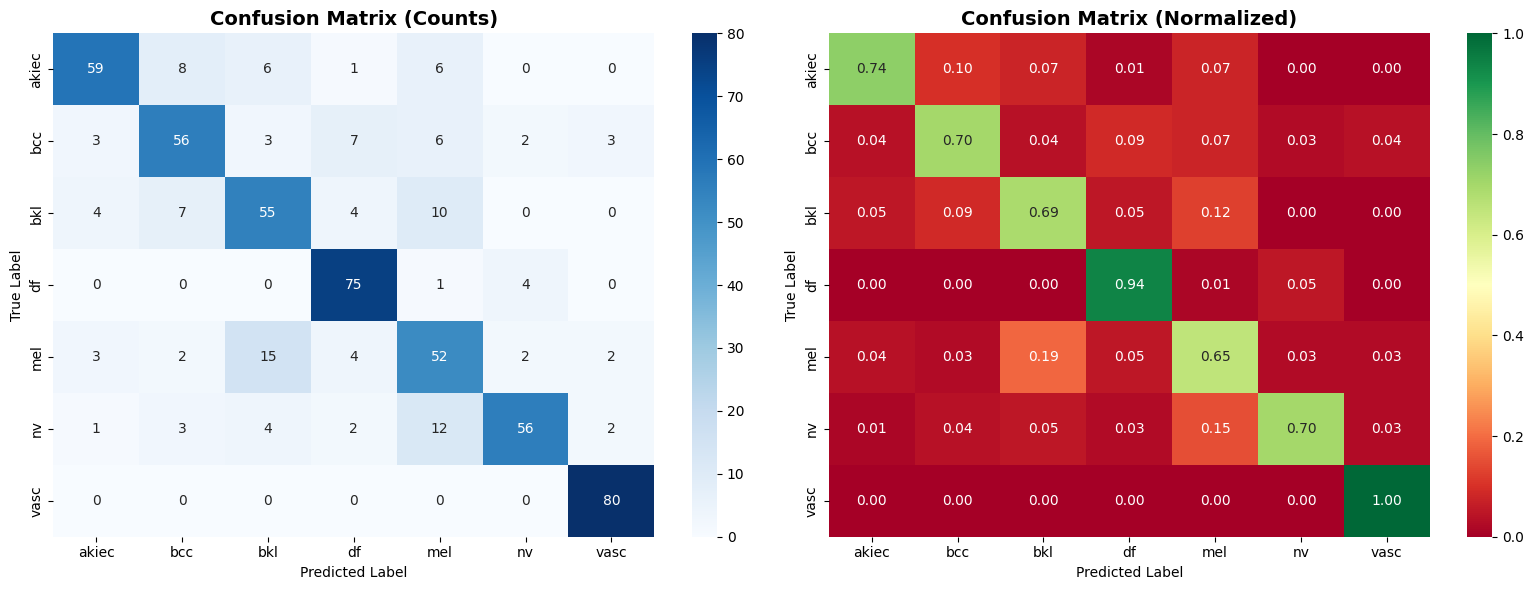

In [24]:
# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


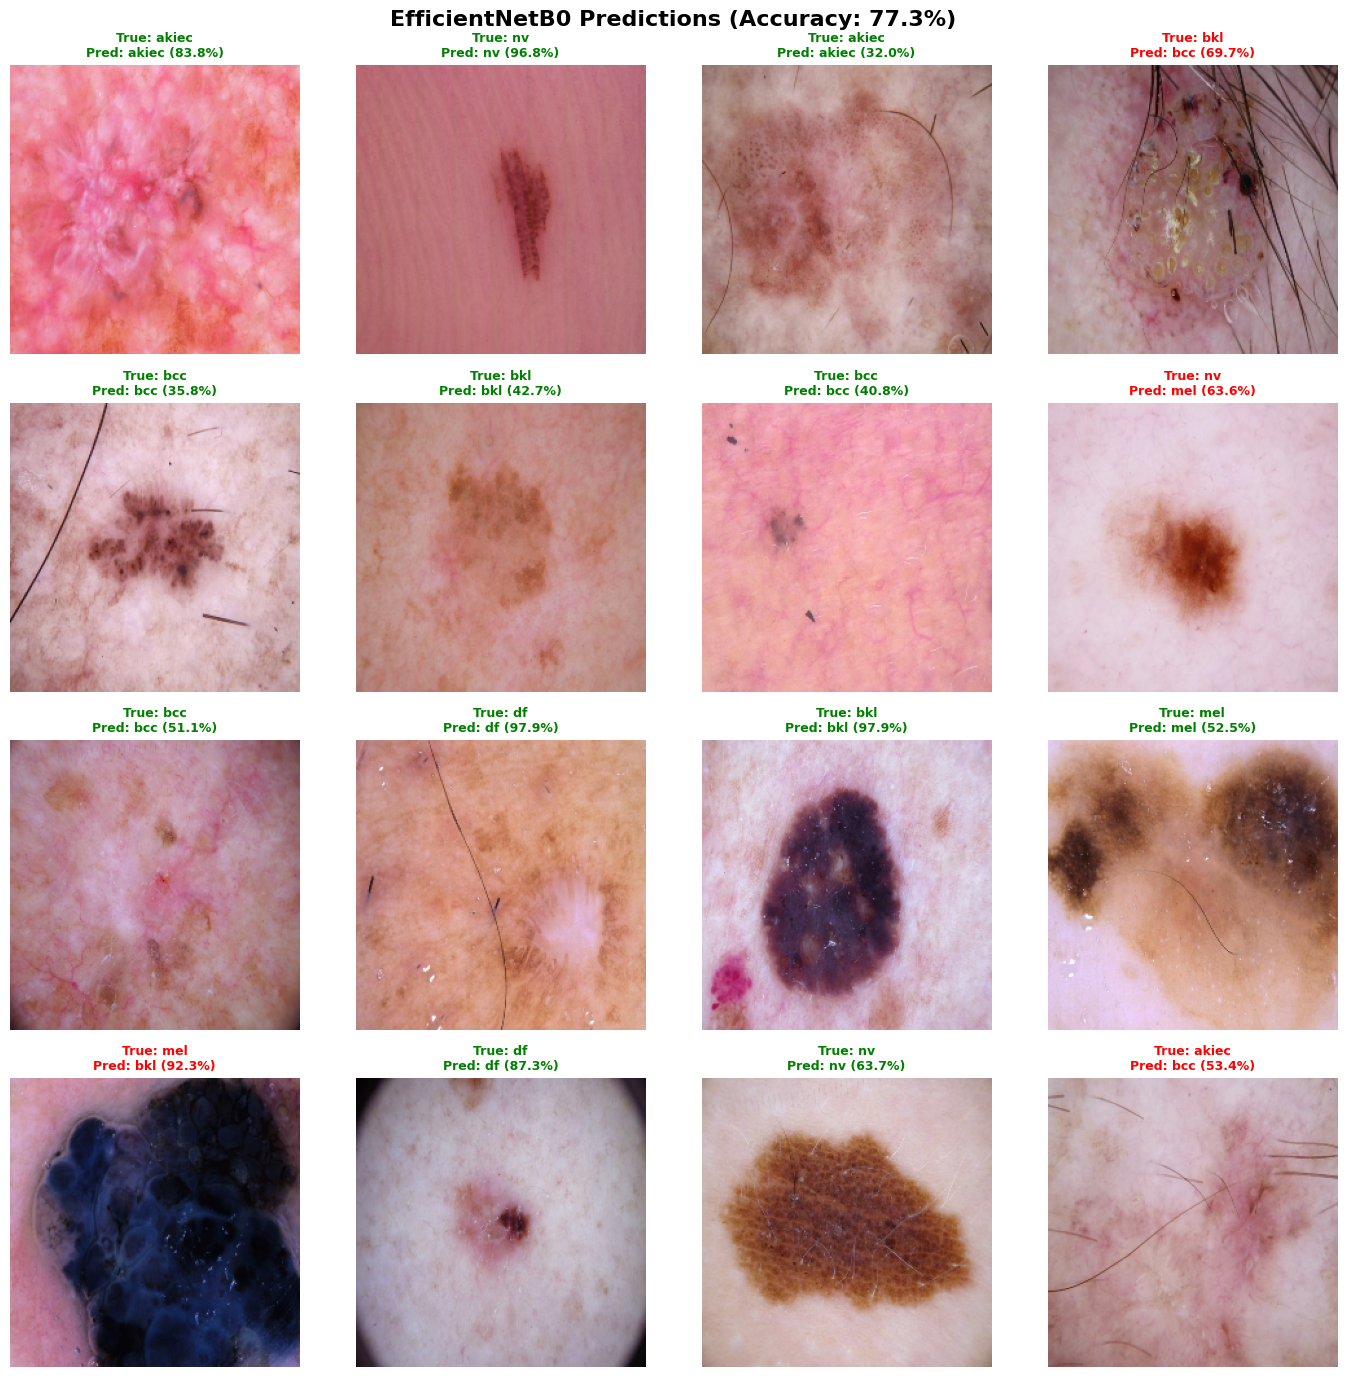

In [26]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
indices = np.random.choice(len(X_test), 16, replace=False)

for idx, i in enumerate(indices):
    ax = axes[idx // 4, idx % 4]
    ax.imshow(X_test_imgs[i].astype('uint8'))

    true_label = class_names[y_test[i]]
    pred_label = class_names[y_pred[i]]
    confidence = y_pred_proba[i][y_pred[i]] * 100

    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                 color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'EfficientNetB0 Predictions (Accuracy: {test_acc*100:.1f}%)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

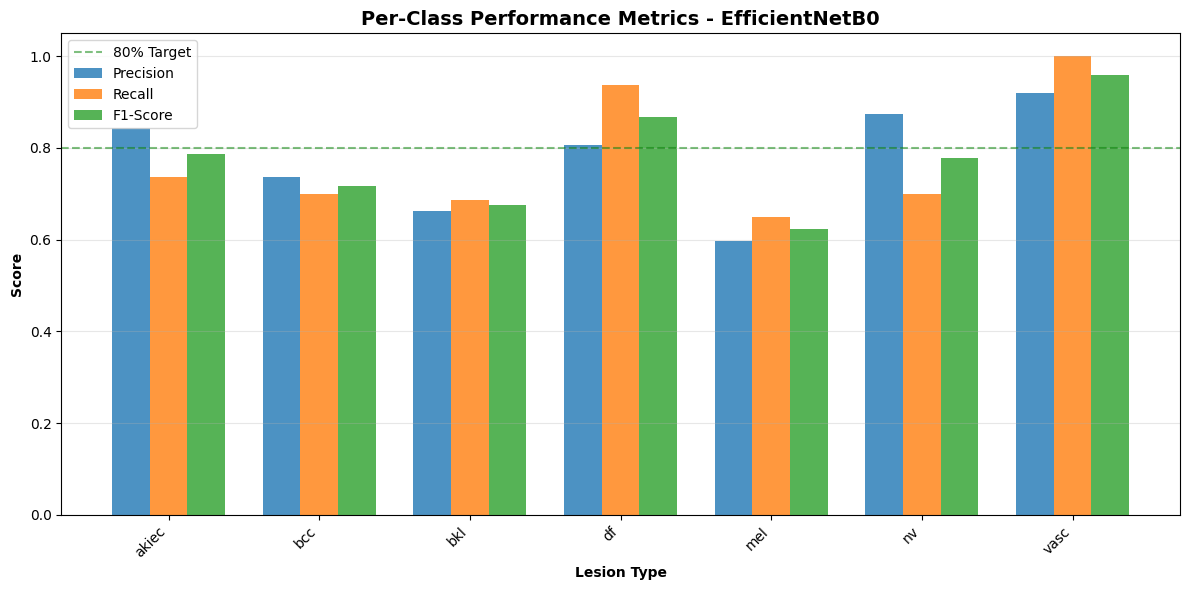

In [27]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=range(7)
)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Recall', alpha=0.8)
bars3 = ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8)

ax.axhline(y=0.80, color='green', linestyle='--', alpha=0.5, label='80% Target')
ax.set_xlabel('Lesion Type', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Per-Class Performance Metrics - EfficientNetB0', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# TTM implemetation and comparison to check accuracy

In [ ]:
##Applying TTM to the current model to increase accuracy

In [30]:
def predict_with_tta(model, images, n_augmentations=5):
    """
    Test-Time Augmentation

    How it works:
    1. Make prediction on original image
    2. Make predictions on 4 augmented versions (rotated, flipped, etc.)
    3. Average all 5 predictions
    4. Return averaged result (more confident and accurate)

    Think of it like: Getting 5 doctors to examine the same patient
    and averaging their diagnoses - more reliable!
    """
    print(f"Applying TTA with {n_augmentations} augmentations...")
    predictions = []

    # 1. Original prediction
    print("  - Predicting on original images...")
    predictions.append(model.predict(images, verbose=0))

    # 2. Create augmentation generator (same as training)
    tta_datagen = ImageDataGenerator(
        rotation_range=15,           # Rotate ±15 degrees
        width_shift_range=0.1,       # Shift left/right 10%
        height_shift_range=0.1,      # Shift up/down 10%
        horizontal_flip=True,        # Flip horizontally
        zoom_range=0.1,              # Zoom in/out 10%
        preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
    )

    # 3. Generate predictions on augmented versions
    for i in range(n_augmentations - 1):
        print(f"  - Predicting on augmentation {i+1}...")
        aug_images = np.array([
            tta_datagen.random_transform(img) for img in images
        ])
        predictions.append(model.predict(aug_images, verbose=0))

    # 4. Average all predictions
    avg_predictions = np.mean(predictions, axis=0)
    print("  ✓ Averaged predictions from all augmentations")

    return avg_predictions

In [31]:
print("="*70)
print("APPLYING TTA TO YOUR CURRENT MODEL")
print("="*70)

# Load your best model (the one that got 77.3%)
model = keras.models.load_model('efficientnet_final.keras')
print("✓ Model loaded: efficientnet_final.keras")

# Preprocess test images (EfficientNet preprocessing)
print("\nPreprocessing test images...")
X_test_preprocessed = tf.keras.applications.efficientnet.preprocess_input(
    X_test_imgs.copy()
)
print(f"✓ Test images ready: {X_test_preprocessed.shape}")

APPLYING TTA TO YOUR CURRENT MODEL
✓ Model loaded: efficientnet_final.keras

Preprocessing test images...
✓ Test images ready: (560, 224, 224, 3)


In [32]:
print("\n" + "="*70)
print("BASELINE: Predictions WITHOUT TTA")
print("="*70)

y_pred_normal = model.predict(X_test_preprocessed, verbose=0)
y_pred_normal_classes = np.argmax(y_pred_normal, axis=1)
acc_normal = accuracy_score(y_test, y_pred_normal_classes)

print(f"\nAccuracy WITHOUT TTA: {acc_normal*100:.2f}%")


BASELINE: Predictions WITHOUT TTA

Accuracy WITHOUT TTA: 77.32%


In [33]:
print("\n" + "="*70)
print("IMPROVED: Predictions WITH TTA")
print("="*70)

# This takes ~2-3 minutes (5x slower but worth it!)
y_pred_tta = predict_with_tta(model, X_test_preprocessed, n_augmentations=5)
y_pred_tta_classes = np.argmax(y_pred_tta, axis=1)
acc_tta = accuracy_score(y_test, y_pred_tta_classes)


IMPROVED: Predictions WITH TTA
Applying TTA with 5 augmentations...
  - Predicting on original images...
  - Predicting on augmentation 1...
  - Predicting on augmentation 2...
  - Predicting on augmentation 3...
  - Predicting on augmentation 4...
  ✓ Averaged predictions from all augmentations


In [37]:
print("\n" + "="*70)
print("DETAILED PER-CLASS PERFORMANCE WITH TTA")
print("="*70)
print("\nWithout TTA (77.3%):")
print(classification_report(y_test, y_pred_normal_classes,
                           target_names=class_names, digits=3))

print("\nWith TTA:")
print(classification_report(y_test, y_pred_tta_classes,
                           target_names=class_names, digits=3))



DETAILED PER-CLASS PERFORMANCE WITH TTA

Without TTA (77.3%):
              precision    recall  f1-score   support

       akiec      0.843     0.738     0.787        80
         bcc      0.737     0.700     0.718        80
         bkl      0.663     0.688     0.675        80
          df      0.806     0.938     0.867        80
         mel      0.598     0.650     0.623        80
          nv      0.875     0.700     0.778        80
        vasc      0.920     1.000     0.958        80

    accuracy                          0.773       560
   macro avg      0.777     0.773     0.772       560
weighted avg      0.777     0.773     0.772       560


With TTA:
              precision    recall  f1-score   support

       akiec      0.798     0.887     0.840        80
         bcc      0.773     0.850     0.810        80
         bkl      0.667     0.625     0.645        80
          df      0.906     0.963     0.933        80
         mel      0.690     0.613     0.649        80
    